In [ ]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Loading Data set
df = pd.read_excel("/content/Car Market Trends Analysis with Car Dekho Data.xlsx")
df.head()


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
# Last Five Rows
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [ ]:
# Number of Rows & Columns
df.shape

(301, 9)

In [ ]:
# Column names
df.columns.to_list()

['Car_Name',
 'Year',
 'Selling_Price',
 'Present_Price',
 'Kms_Driven',
 'Fuel_Type',
 'Seller_Type',
 'Transmission',
 'Owner']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [ ]:
# Statistical Info
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Car_Name,301,98,city,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,301.0,NaN,NaN,NaN,2013.627907,2.891554,2003.0,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,NaN,NaN,NaN,4.661296,5.082812,0.1,0.9,3.6,6.0,35.0
Present_Price,301.0,NaN,NaN,NaN,7.628472,8.644115,0.32,1.2,6.4,9.9,92.6
Kms_Driven,301.0,NaN,NaN,NaN,36947.20598,38886.883882,500.0,15000.0,32000.0,48767.0,500000.0
Fuel_Type,301,3,Petrol,239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Seller_Type,301,2,Dealer,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,301,2,Manual,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,301.0,NaN,NaN,NaN,0.043189,0.247915,0.0,0.0,0.0,0.0,3.0


In [ ]:
# Data Quality Check
duplicate_count = df.duplicated().sum()
print('Duplicate Rows:',duplicate_count)

Duplicate Rows: 0


In [ ]:
df = df.drop_duplicates().copy()
print('Duplicates remaining:',df.duplicated().sum())

Duplicates remaining: 0


In [ ]:
# Finding Missing Values
missing = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Missing %': (df.isna().mean() * 100).round(2)
})

missing = missing[missing['Missing Count'] > 0]
missing.sort_values('Missing Count', ascending=False)

,Missing Count,Missing %


In [ ]:
average_price = df['Selling_Price'].mean()
median_price = df['Selling_Price'].median()

print(f'Average price: ${average_price:,.2f}')
print(f'Median price: ${median_price:,.2f}')

Average price: $4.66
Median price: $3.60


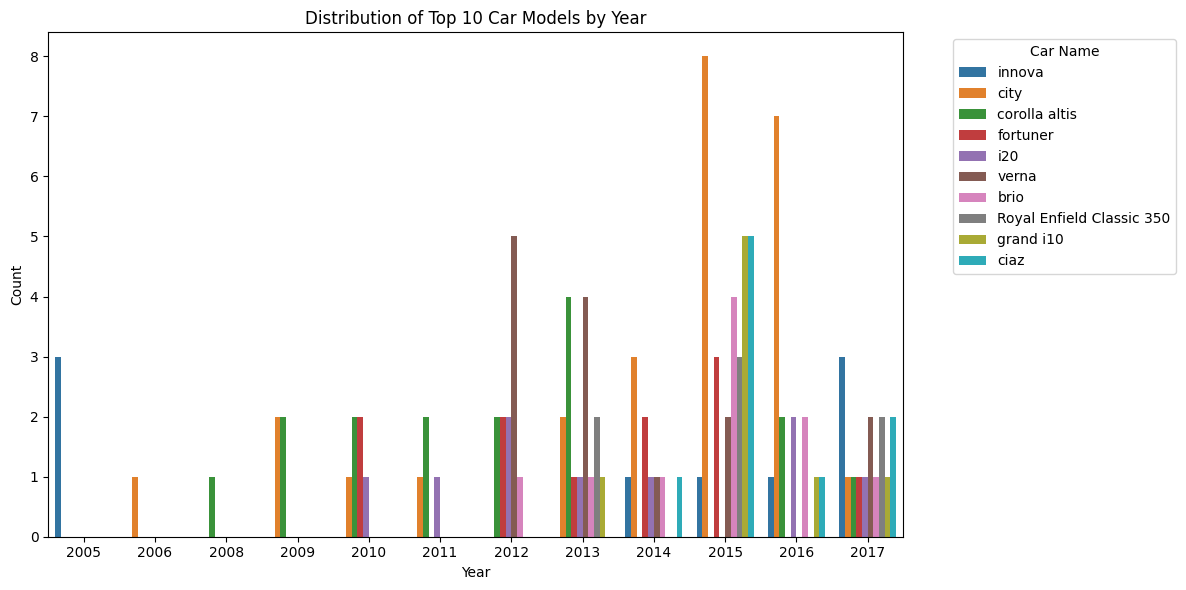

In [ ]:
# Trends between Car_Name and Year for top 10 car models
top_cars = df['Car_Name'].value_counts().nlargest(10).index
df_top = df[df['Car_Name'].isin(top_cars)]

plt.figure(figsize=(12, 6))
sns.countplot(data=df_top, x='Year', hue='Car_Name')
plt.title('Distribution of Top 10 Car Models by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend(title='Car Name', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

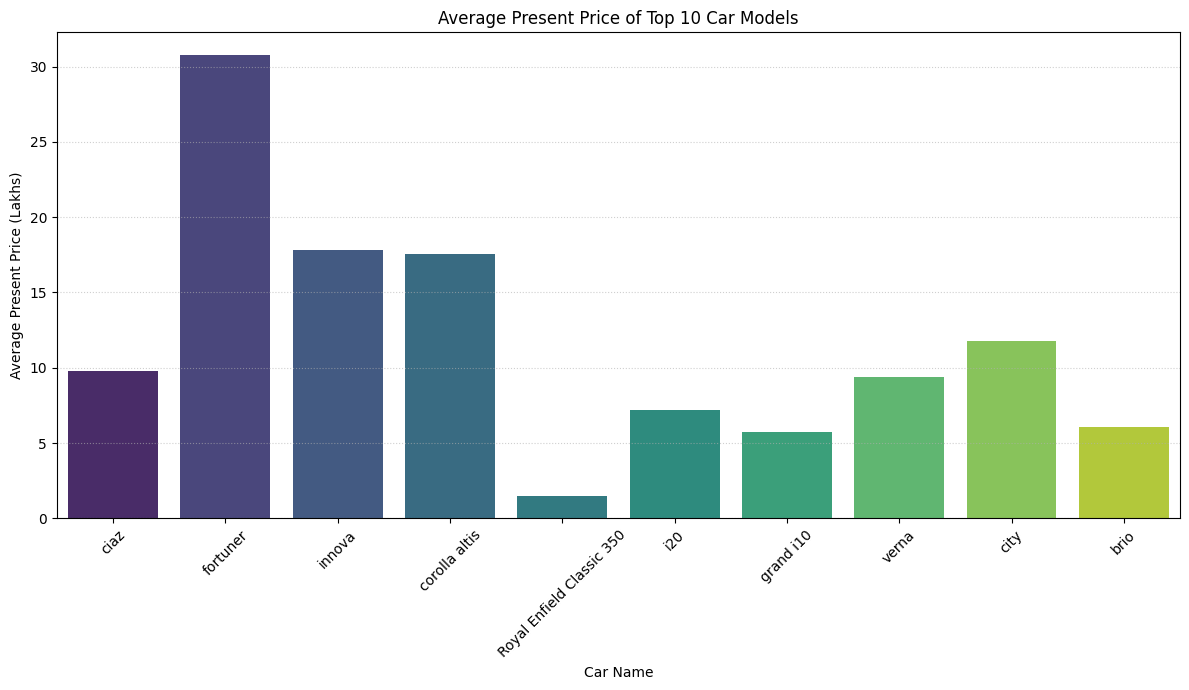

In [ ]:
# Visualizing Average Present Price for Top 10 Car Models
top_cars = df['Car_Name'].value_counts().nlargest(10).index
df_top = df[df['Car_Name'].isin(top_cars)]

plt.figure(figsize=(12, 7))
# Updated to address FutureWarnings: using errorbar=None and assigning x to hue
sns.barplot(data=df_top, x='Car_Name', y='Present_Price', errorbar=None, hue='Car_Name', palette='viridis', legend=False)

plt.title('Average Present Price of Top 10 Car Models')
plt.xlabel('Car Name')
plt.ylabel('Average Present Price (Lakhs)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

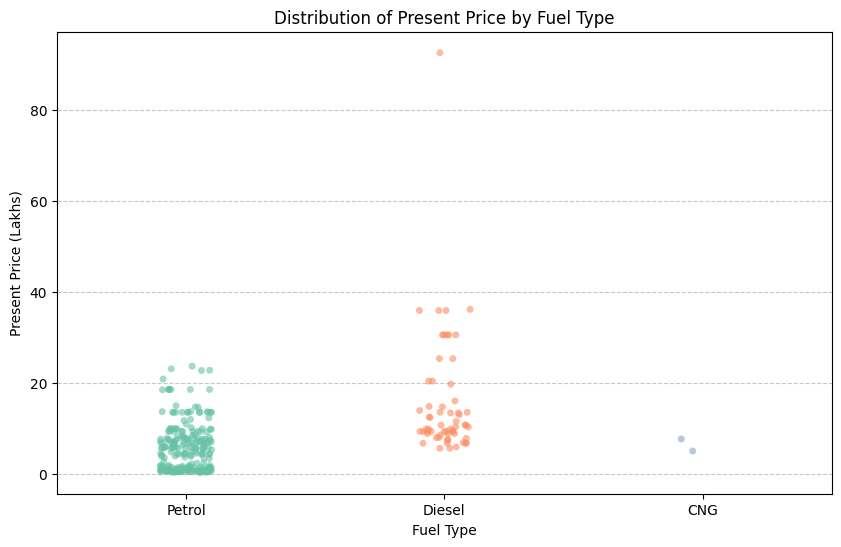

In [ ]:
# Scatter plot for Present Price vs Fuel Type
plt.figure(figsize=(10, 6))
sns.stripplot(data=df, x='Fuel_Type', y='Present_Price', hue='Fuel_Type', palette='Set2', alpha=0.6, jitter=True)

plt.title('Distribution of Present Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Present Price (Lakhs)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

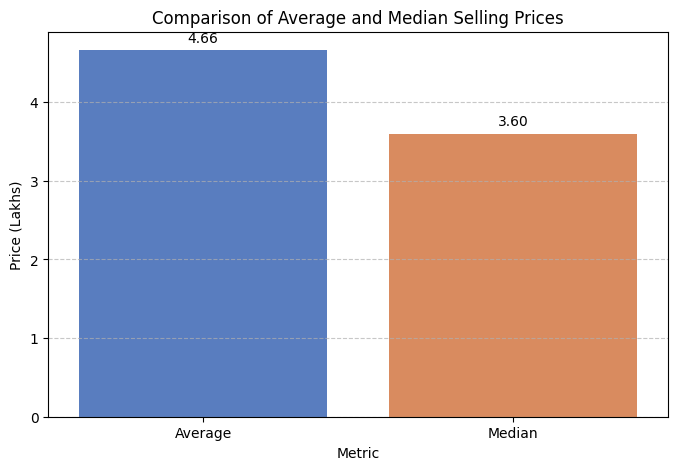

In [ ]:
# Visualizing Average vs Median Selling Price
stats_df = pd.DataFrame({
    'Metric': ['Average', 'Median'],
    'Price': [average_price, median_price]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=stats_df, x='Metric', y='Price', hue='Metric', palette='muted', legend=False)

plt.title('Comparison of Average and Median Selling Prices')
plt.ylabel('Price (Lakhs)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adding text labels on top of bars
for i, price in enumerate(stats_df['Price']):
    plt.text(i, price + 0.1, f'{price:.2f}', ha='center')

plt.show()

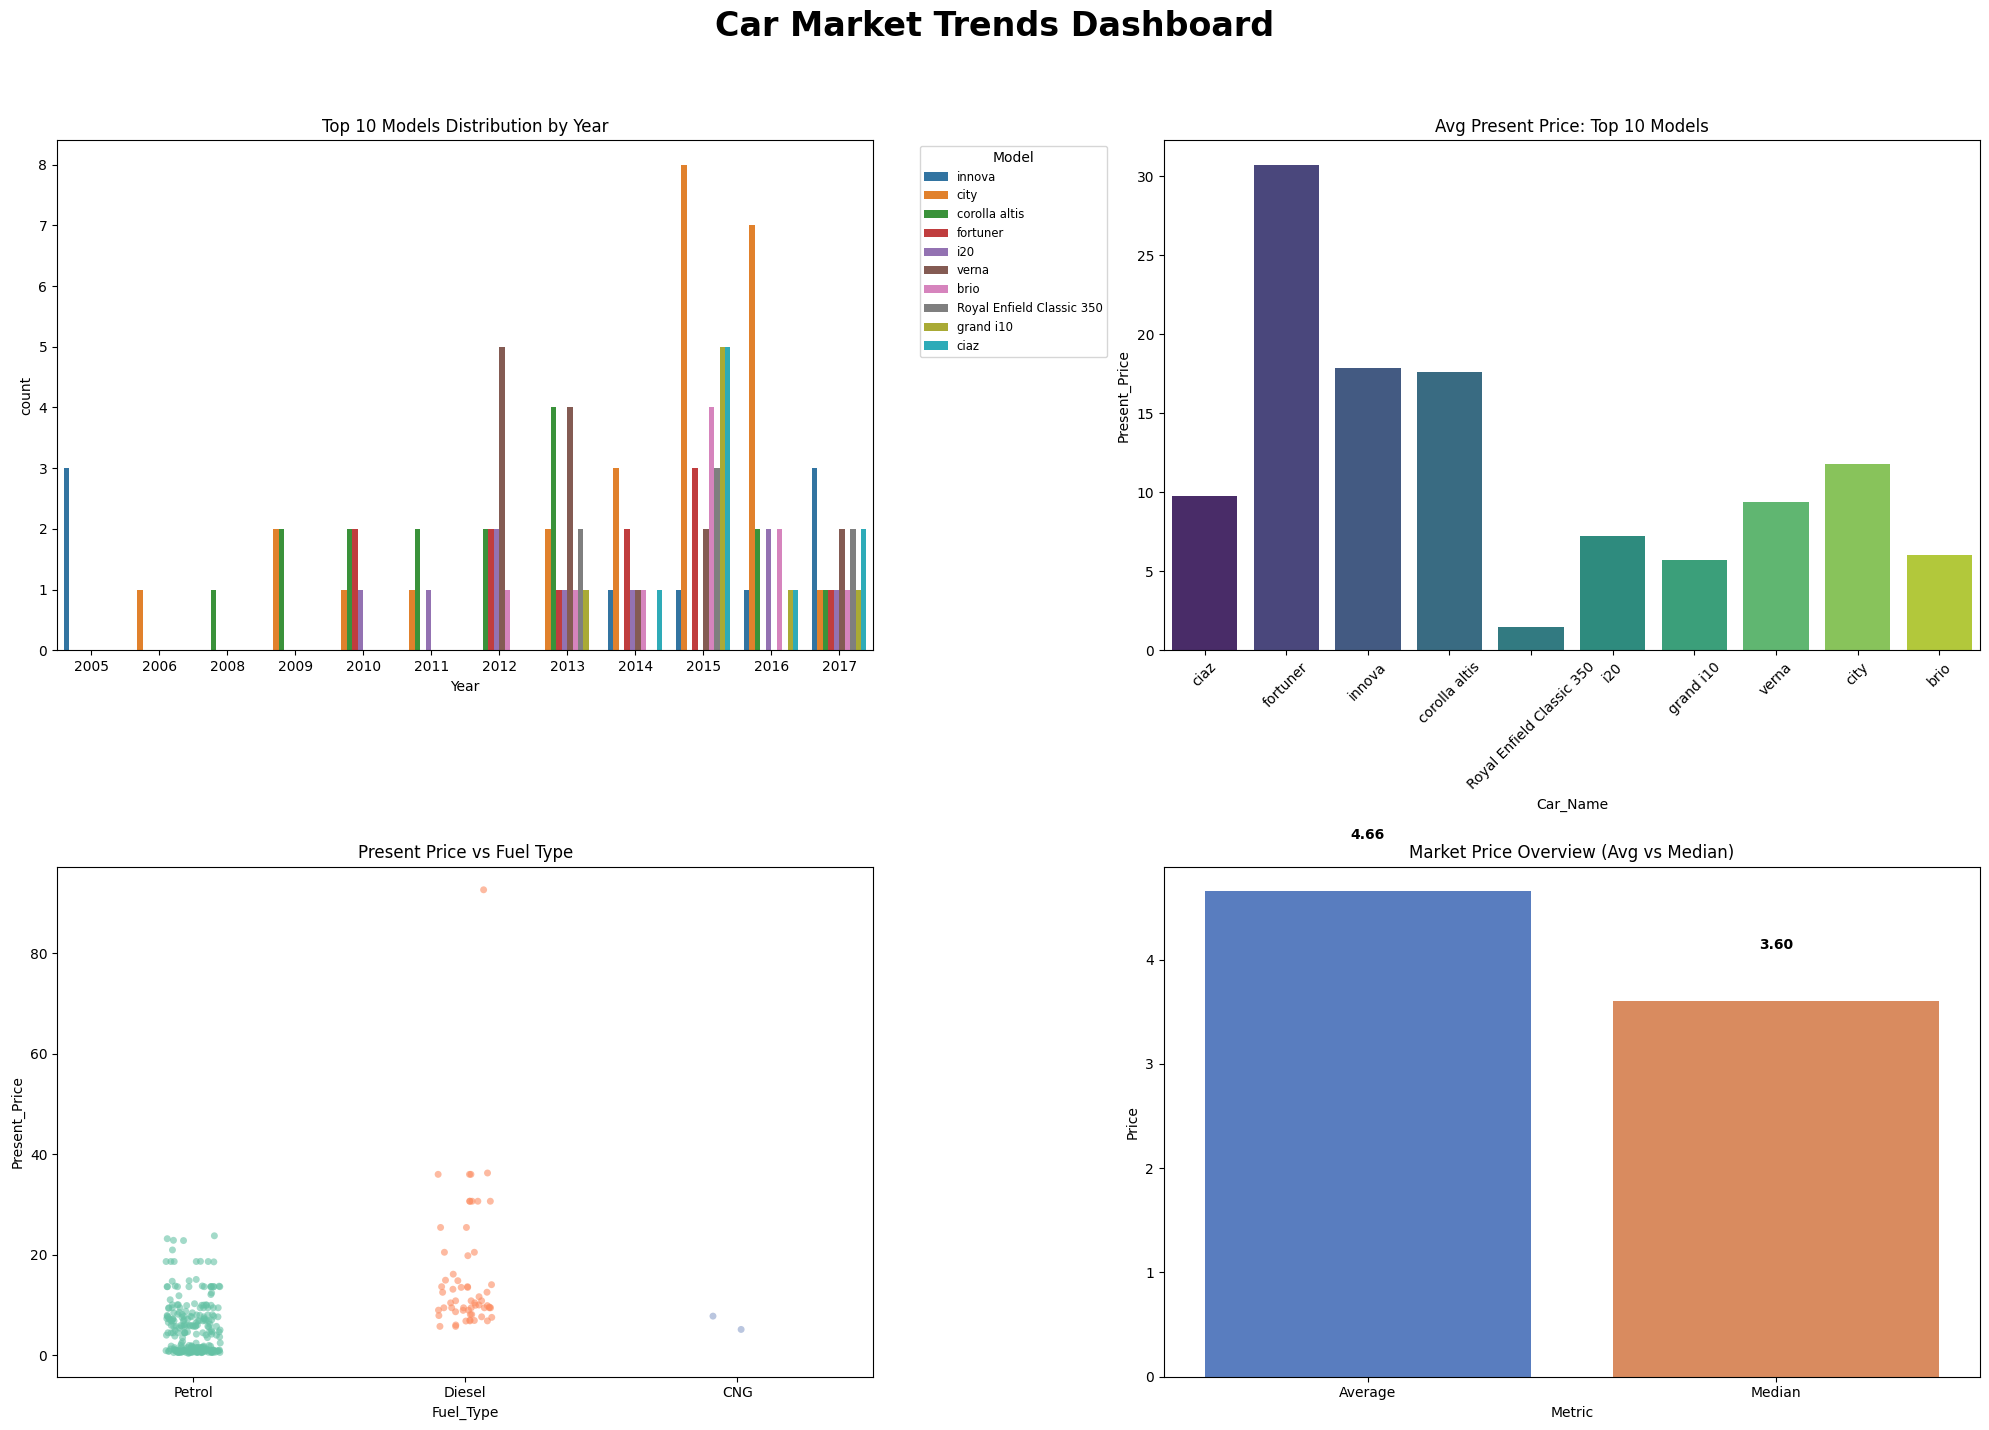

In [ ]:
# Consolidated Dashboard of Car Market Analysis
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
fig.suptitle('Car Market Trends Dashboard', fontsize=24, fontweight='bold')

# 1. Distribution of Top 10 Car Models by Year
top_cars = df['Car_Name'].value_counts().nlargest(10).index
df_top = df[df['Car_Name'].isin(top_cars)]
sns.countplot(ax=axes[0, 0], data=df_top, x='Year', hue='Car_Name')
axes[0, 0].set_title('Top 10 Models Distribution by Year')
axes[0, 0].legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

# 2. Average Present Price of Top 10 Car Models
sns.barplot(ax=axes[0, 1], data=df_top, x='Car_Name', y='Present_Price', errorbar=None, hue='Car_Name', palette='viridis', legend=False)
axes[0, 1].set_title('Avg Present Price: Top 10 Models')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Distribution of Present Price by Fuel Type
sns.stripplot(ax=axes[1, 0], data=df, x='Fuel_Type', y='Present_Price', hue='Fuel_Type', palette='Set2', alpha=0.6, jitter=True, legend=False)
axes[1, 0].set_title('Present Price vs Fuel Type')

# 4. Average vs Median Selling Price
stats_df = pd.DataFrame({'Metric': ['Average', 'Median'], 'Price': [df['Selling_Price'].mean(), df['Selling_Price'].median()]})
sns.barplot(ax=axes[1, 1], data=stats_df, x='Metric', y='Price', hue='Metric', palette='muted', legend=False)
axes[1, 1].set_title('Market Price Overview (Avg vs Median)')
for i, price in enumerate(stats_df['Price']):
    axes[1, 1].text(i, price + 0.5, f'{price:.2f}', ha='center', fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()